<a href="https://colab.research.google.com/github/Ritesh-panda/datascience-learnings/blob/main/Regression_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
data=pd.read_csv('/content/50_Startups.csv')

In [5]:
data.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [11]:
# Divide the dataset into independent (x) and dependent (y) variables
# x: All rows, all columns except the last one
x = data.iloc[:, :-1].values
# y: All rows, only the last column (Profit)
y = data.iloc[:, -1].values

In [12]:
# split the data into training and testing set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

print("Split successful!")
print("Training samples:", x_train.shape[0])
print("Testing samples:", x_test.shape[0])

Split successful!
Training samples: 40
Testing samples: 10


In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np

# 1. One-Hot Encoding for categorical 'State' column (index 3)
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [3])], remainder='passthrough')
x_encoded = np.array(ct.fit_transform(x))

# 2. Re-split the data
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_encoded, y, test_size=0.2, random_state=0)

# 3. Feature Scaling
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

print("Categorical data encoded and feature scaling applied successfully!")

Categorical data encoded and feature scaling applied successfully!


In [30]:
#creating the linear regression model
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(x_train,y_train)

LinearRegression()

In [31]:
y_pred=regressor.predict(x_test)

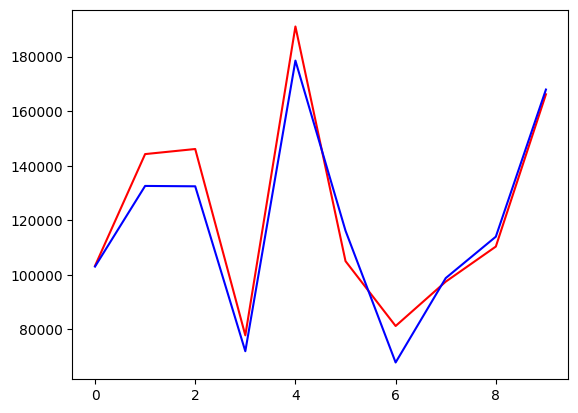

In [37]:
#plot the graph
plt.plot(y_test, color='red', label='train')
plt.plot(y_pred, color='blue', label='test')

In [39]:
#regression metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

Mean Squared Error: 83502864.03
Mean Absolute Error: 7514.29
R2 Score: 0.93


In [42]:
rmse=np.sqrt(mse)
print(rmse)

9137.99015279496


In [45]:
n=x_test.shape[0]
k=x_test.shape[1]
adj_r2=1-((1-r2)*(n-1)/(n-k-1))
print(adj_r2)

0.8041205419847268
